<a href="https://colab.research.google.com/github/dagudelo30/Series-de-tiempo---Javeriana-Cali/blob/main/intro-moving_average/intro_moving_average.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [110]:
# Dependencias necesarias para el notebook (Churn - Random Forest y SVM)
# Usa el Python del kernel para evitar "pip is not recognized". Ejecutar solo una vez.
import sys
!{sys.executable} -m pip install --quiet numpy pandas matplotlib scikit-learn statsmodels


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\usuario\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


# Pronósticos basados en series de tiempo 

## Diego Fernando Agudelo
## Universidad Javeriana-Cali
## diegoagudelo30@gmail.com


## **1. Carga de paquetes**

In [111]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error


Este documento presenta una breve introducción a la construcción de objetos de series de tiempo y el cálculo de pronósticos con modelos de suavización.

Para este ejercicio emplearemos la información disponible en el archivo datosEmpleo.xlsx. En ese archivo econtrarán la tasa de desempleo mensual de las 13 principales ciudades en Colombia (TD_13ciudades). El archivo también contiene series mensuales para las 13 principales ciudades de Colombia el número de ocupados en miles de personas (Ocupados), los desocupados (Desocupados) y los inactivos (Inactivos).

## **2. Carga de datos**

Nuestra primera tarea será leer el archivo de Excel. Para eso podemos emplear el paquete Pandas. Carguemos los datos en un objeto que denominaremos data.

In [112]:
data = pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


En este caso los datos fueron leídos como un data frame y adicionalmente la columna "mes" fue seleccionada como indice, con el dataframe de esta forma sera más facil trabajar las series de tiempo.

A continuación se gráfica la tasa de desempleo.



(222, 4)


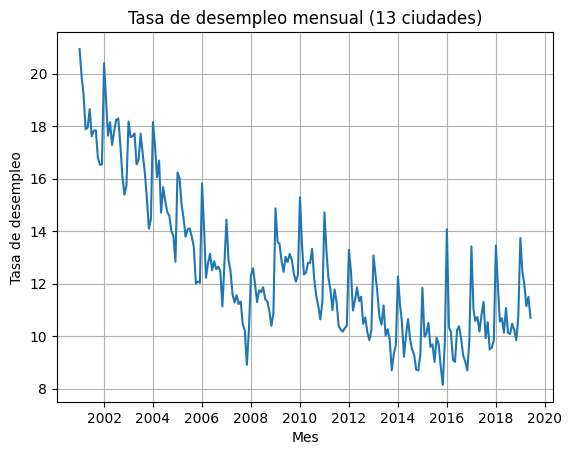

In [113]:
# imprimiendo el tamano del dataframe
print(data.shape)

# Graficando los datos
plt.title("Tasa de desempleo mensual (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Tasa de desempleo")
plt.plot(data[["TD_13ciudades"]])
plt.grid()
plt.show()

## **3. Encontrando los componentes de una serie de tiempo**

En algunas ocasiones puede ser útil empezar nuestro análisis descomponiendo la serie de tiempo en sus componentes: **tendencia**, **estacionalidad** y **componente puramente aleatorio**. Una forma de hacer esto es empleando la función seasonal_decompose.

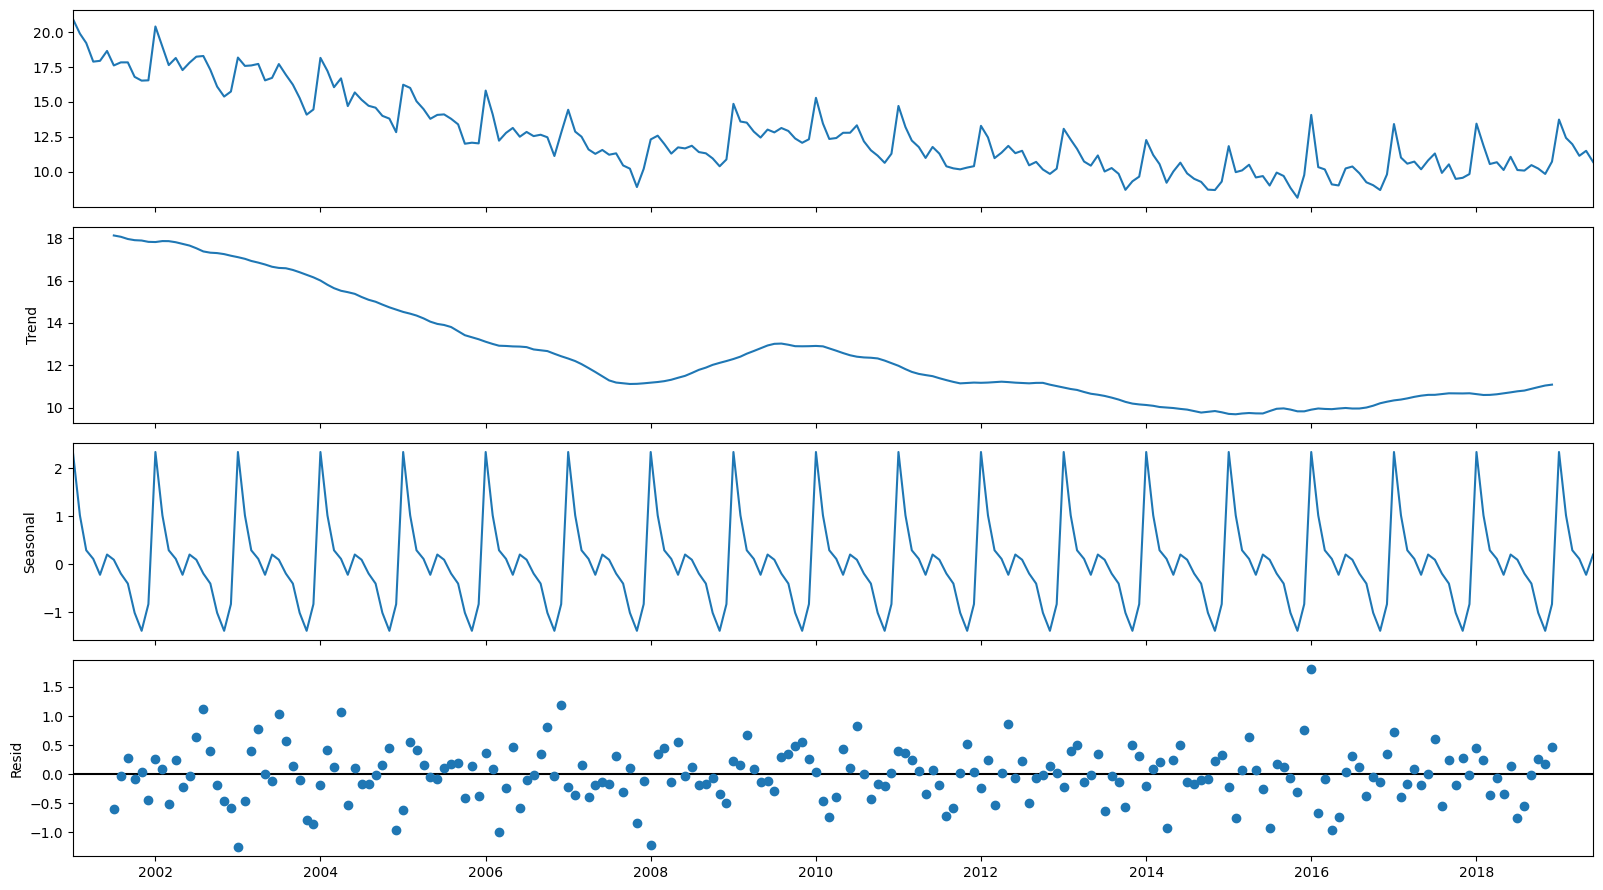

In [114]:
td_componentes = seasonal_decompose(data[["TD_13ciudades"]],model="additive")
fig = td_componentes.plot()
fig.set_size_inches((16, 9))
fig.tight_layout()
plt.show()

Asi se extrae cada elemento de la descomposición de la serie.

In [115]:
td_componentes.seasonal
#td_componentes.trend
#td_componentes.resid

mes
2001-01-01    2.337888
2001-02-01    1.017106
2001-03-01    0.290193
2001-04-01    0.110715
2001-05-01   -0.220208
                ...   
2019-02-01    1.017106
2019-03-01    0.290193
2019-04-01    0.110715
2019-05-01   -0.220208
2019-06-01    0.201178
Name: seasonal, Length: 222, dtype: float64

Podemos observar el componente estacional marcado en la serie, una tendencia no lineal de los datos y la parte aleatoria.

Es importante mencionar que esta descomposición se emplea solo como referencia para iniciar el análisis.

Antes de entrar a trabajar con los métodos de suavizamiento, vale la pena anotar que una forma sencilla y rápida para quitar el componente estacional (desestacionalizar) es restarle a la serie el componente estacional encontrado en la descomposición. Es decir,

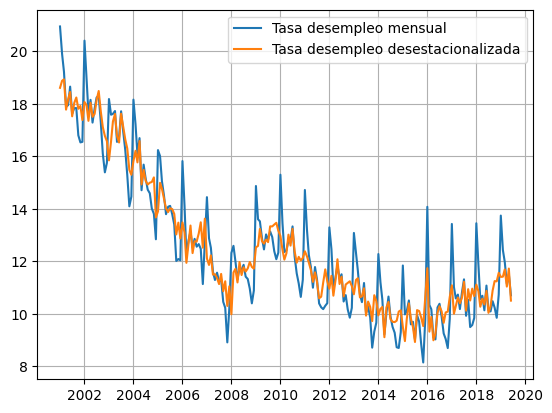

In [116]:
td_desestacionalizada = data["TD_13ciudades"]-td_componentes.seasonal

plt.plot(data[["TD_13ciudades"]],label="Tasa desempleo mensual")
plt.plot(td_desestacionalizada,label="Tasa desempleo desestacionalizada")
plt.legend()
plt.grid()
plt.show()


## **4. Protocolo de evaluación**

Antes de continuar es importante guardar una parte de la muestra para evaluar el comportamiento de los modelos por fuera de muestra (out-of-sample). Guardemos un año de datos.

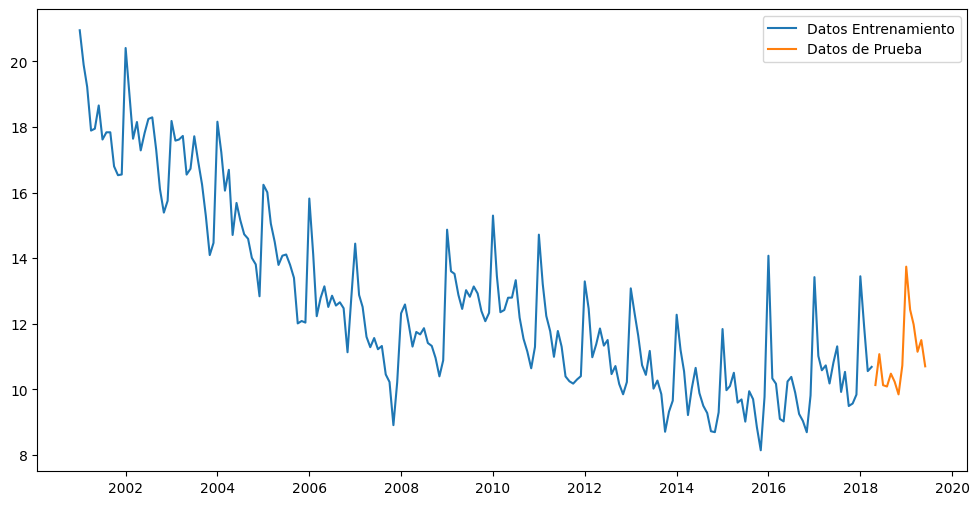

In [117]:
train_len = 208
train_td = data[["TD_13ciudades"]][:train_len]
test_td = data[["TD_13ciudades"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td,label="Datos de Prueba")
plt.legend()
plt.show()

In [118]:
train_td

,TD_13ciudades
mes,
2001-01-01,20.946380
2001-02-01,19.894213
2001-03-01,19.221565
2001-04-01,17.888575
2001-05-01,17.945654
...,...
2017-12-01,9.837395
2018-01-01,13.446245
2018-02-01,11.874973


In [119]:
test_td

,TD_13ciudades
mes,
2018-05-01,10.129211
2018-06-01,11.071347
2018-07-01,10.125100
2018-08-01,10.085244
2018-09-01,10.476567
2018-10-01,10.230811
2018-11-01,9.844539
2018-12-01,10.725865
2019-01-01,13.739328


## **5. Promedio movil**

El promedio móvil está dado por:

$$ F_{t + 1}=\frac{Y_{t} + Y_{t-1} + Y_{t-(k-1)} }{ k} $$

El método de los promedios móviles utiliza el promedio de los $k$
valores de datos más recientes en la serie de tiempo como el
pronóstico para el siguiente periodo.

El término móvil indica que, mientras se dispone de una nueva
observación para la serie de tiempo, reemplaza a la observación más
antigua de la ecuación anterior y se calcula un promedio nuevo.
Como resultado, el promedio cambiará, o se moverá, conforme surjan
nuevas observaciones.

$Y_{t}$ = Observación en el período t

$F_{t}$ = Pronóstico en el período t

In [120]:
## Considerando el dato actual
ma_2= train_td.rolling(2,min_periods=2).mean()
ma_3= train_td.rolling(3,min_periods=2).mean()
ma_4= train_td.rolling(4,min_periods=2).mean()
ma_5= train_td.rolling(5,min_periods=2).mean()

In [121]:
## Sin considerar el dato actual
ma_2= train_td.shift().rolling(2,min_periods=2).mean()
ma_3= train_td.shift().rolling(3,min_periods=2).mean()
ma_4= train_td.shift().rolling(4,min_periods=2).mean()
ma_5= train_td.shift().rolling(5,min_periods=2).mean()


In [122]:
def fore_ma(datos,w,h):
  data=datos.copy()
  for x in range(1,h+1):
    ind = data.index[-1]
    value = ind + pd.DateOffset(months=1)
    data.loc[value]= data[-w:].mean()
  return data[-h:]

In [123]:
ma_2_f= fore_ma(train_td,2,14)
ma_3_f= fore_ma(train_td,3,14)
ma_4_f= fore_ma(train_td,4,14)
ma_5_f= fore_ma(train_td,5,14)

In [124]:
test_td

,TD_13ciudades
mes,
2018-05-01,10.129211
2018-06-01,11.071347
2018-07-01,10.125100
2018-08-01,10.085244
2018-09-01,10.476567
2018-10-01,10.230811
2018-11-01,9.844539
2018-12-01,10.725865
2019-01-01,13.739328


In [125]:
ma_2_f

,TD_13ciudades
mes,
2018-05-01,10.618803
2018-06-01,10.651004
2018-07-01,10.634904
2018-08-01,10.642954
2018-09-01,10.638929
2018-10-01,10.640941
2018-11-01,10.639935
2018-12-01,10.640438
2019-01-01,10.640187


In [126]:
rmse_ma_2 = np.sqrt(mean_squared_error(test_td,ma_2_f ))
rmse_ma_3 = np.sqrt(mean_squared_error(test_td,ma_3_f ))
rmse_ma_4 = np.sqrt(mean_squared_error(test_td,ma_4_f ))
rmse_ma_5 = np.sqrt(mean_squared_error(test_td,ma_5_f ))

In [127]:
print( rmse_ma_2, rmse_ma_3 ,rmse_ma_4 ,rmse_ma_5)

1.1147962992873541 1.079289141194038 1.0913829514823736 1.079379141938296


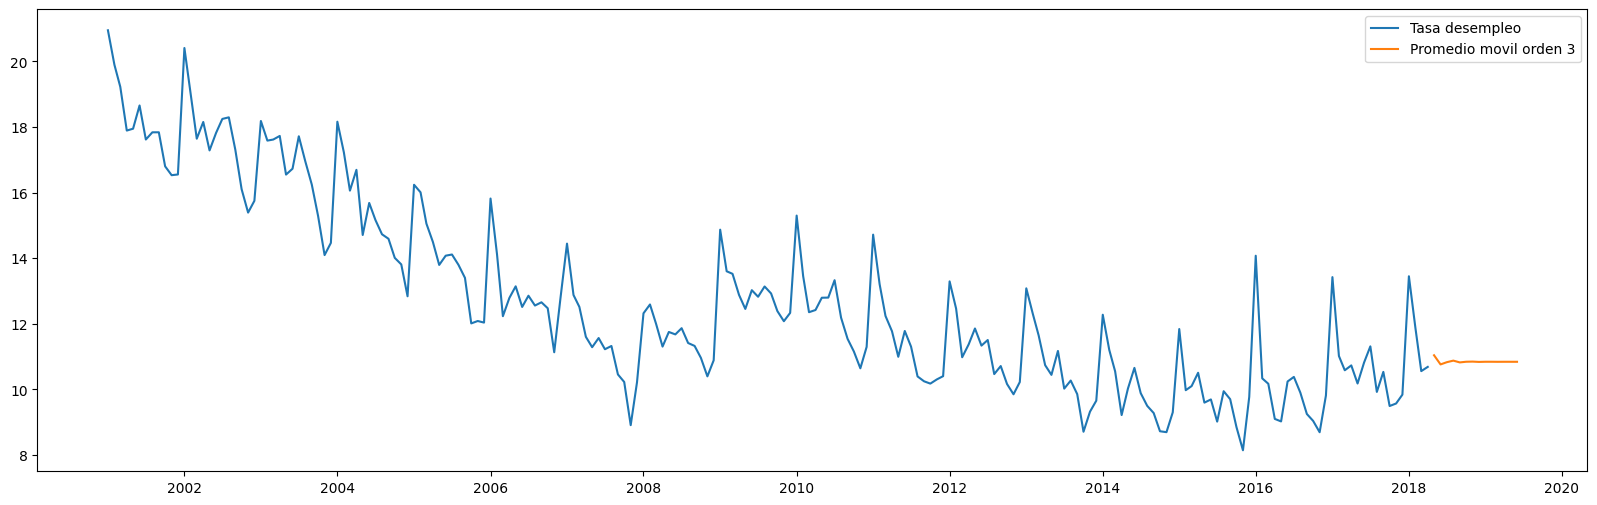

In [128]:
fig = plt.figure(figsize=(20, 6))
plt.plot(train_td,label="Tasa desempleo")
plt.plot(ma_3_f,label="Promedio movil orden 3")
plt.legend()
plt.show()

## **6. Ejercicio**

Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encuentre el mejor pronóstico para los próximos 6 meses. Escriba un breve informe de máximo una página de texto que explique cómo llega a sus proyeccciones y presente las proyecciones. Aclare en el texto cuáles serían las limitaciones de sus pronósticos.

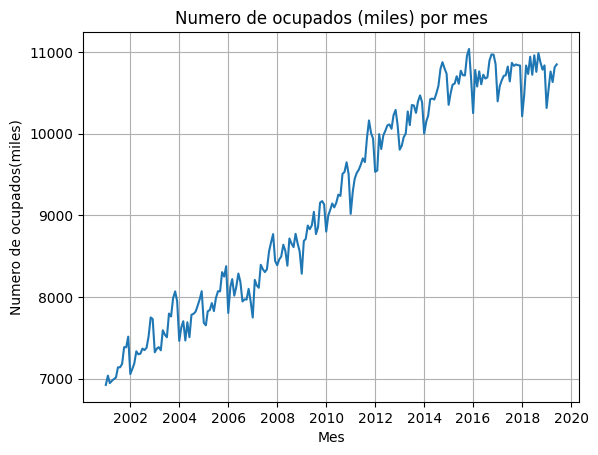

In [129]:
# Graficando los datos
plt.title("Numero de ocupados (miles) por mes")
plt.xlabel("Mes")
plt.ylabel("Numero de ocupados(miles)")
plt.plot(data[["Ocupados"]])
plt.grid()
plt.show()

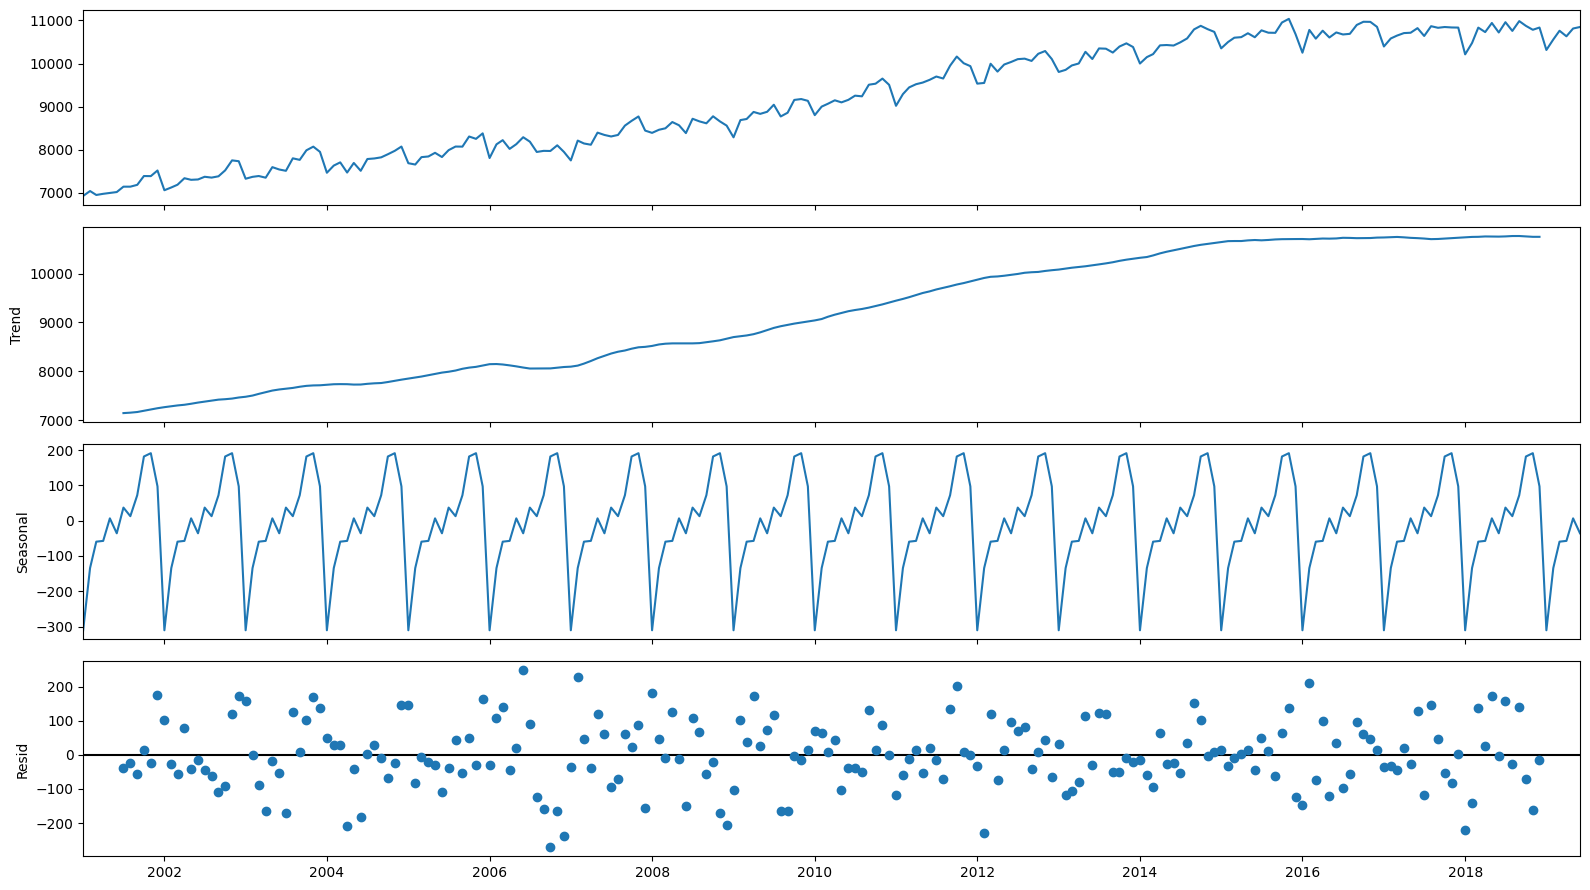

In [130]:
ocupados_componentes = seasonal_decompose(data[["Ocupados"]],model="additive")
fig1 = ocupados_componentes.plot()
fig1.set_size_inches((16, 9))
fig1.tight_layout()
plt.show()

In [131]:
ocupados_componentes.seasonal

mes
2001-01-01   -310.570069
2001-02-01   -134.331549
2001-03-01    -59.585841
2001-04-01    -57.385905
2001-05-01      6.435912
                 ...    
2019-02-01   -134.331549
2019-03-01    -59.585841
2019-04-01    -57.385905
2019-05-01      6.435912
2019-06-01    -35.859993
Name: seasonal, Length: 222, dtype: float64

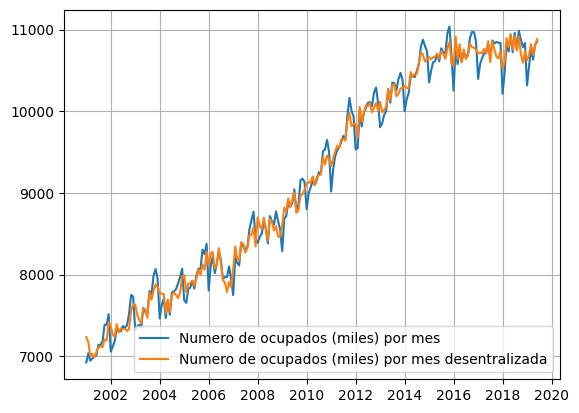

In [132]:
ocupados_desestacionalizada = data["Ocupados"]-ocupados_componentes.seasonal

plt.plot(data[["Ocupados"]],label="Numero de ocupados (miles) por mes")
plt.plot(ocupados_desestacionalizada,label="Numero de ocupados (miles) por mes desentralizada")
plt.legend()
plt.grid()
plt.show()

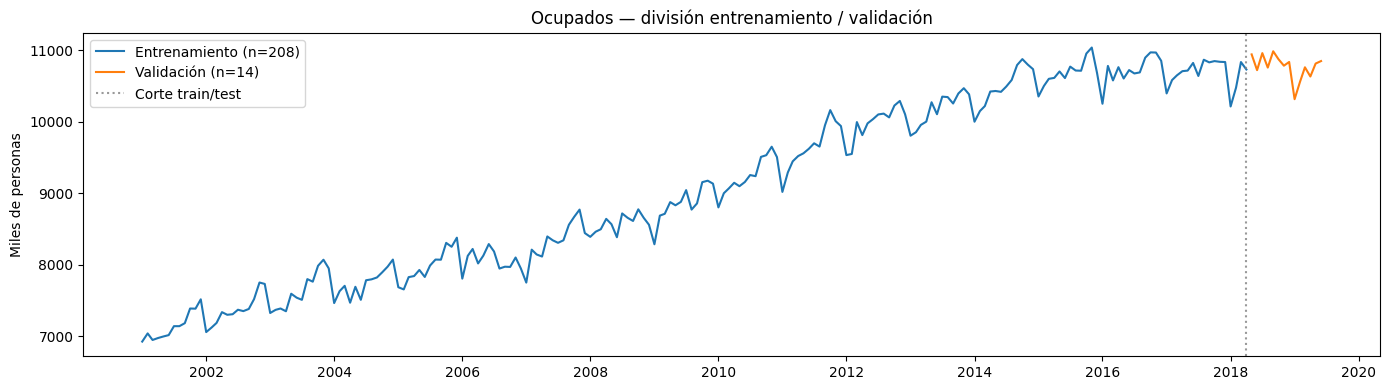

In [ ]:
serie_ocup = data["Ocupados"].astype(float).asfreq("MS")
train_len = 208
train_ocup = serie_ocup.iloc[:train_len]
test_ocup = serie_ocup.iloc[train_len:]
h_test = len(test_ocup)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_ocup.index, train_ocup.values, label=f"Entrenamiento (n={len(train_ocup)})")
ax.plot(test_ocup.index, test_ocup.values, label=f"Validación (n={len(test_ocup)})", color="C1")
ax.axvline(train_ocup.index[-1], color="gray", linestyle=":", alpha=0.8, label="Corte train/test")
ax.set_ylabel("Miles de personas")
ax.set_title("Ocupados — división entrenamiento / validación")
ax.legend()
plt.tight_layout()
plt.show()


### Ejercicio 6 — Promedio móvil

A partir de aquí se aplica `shift().rolling` para la media móvil en entrenamiento y **`fore_mao`** para pronosticar el tramo de validación y, al final, **6 meses** adelante con el orden **w** que minimiza el RMSE.


In [ ]:
mao_2 = train_ocup.shift().rolling(2, min_periods=2).mean()
mao_3 = train_ocup.shift().rolling(3, min_periods=2).mean()
mao_4 = train_ocup.shift().rolling(4, min_periods=2).mean()
mao_5 = train_ocup.shift().rolling(5, min_periods=2).mean()

# Pronósticos fuera de muestra con fore_ma (debe estar definida antes en el notebook)
mao_2_f = fore_ma(train_ocup, 2, h_test)
mao_3_f = fore_ma(train_ocup, 3, h_test)
mao_4_f = fore_ma(train_ocup, 4, h_test)
mao_5_f = fore_ma(train_ocup, 5, h_test)


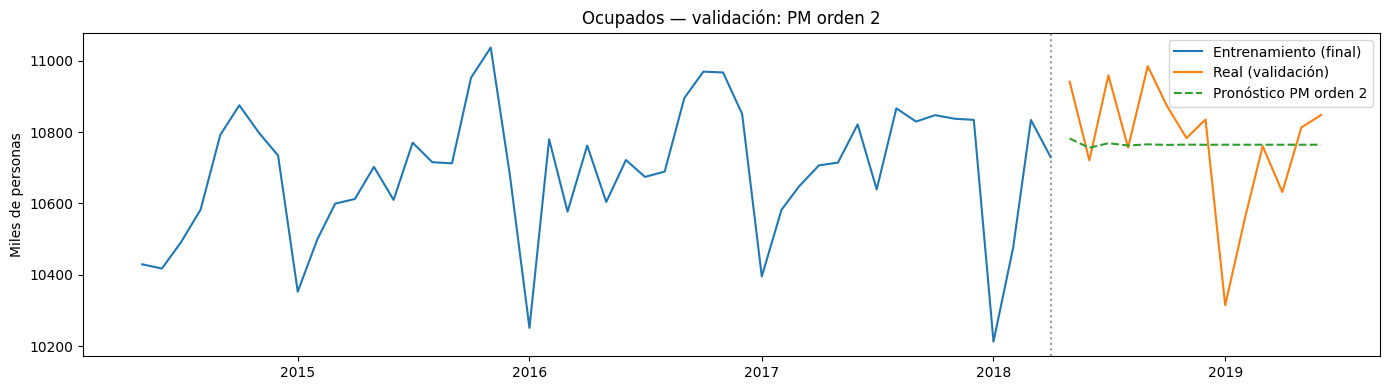

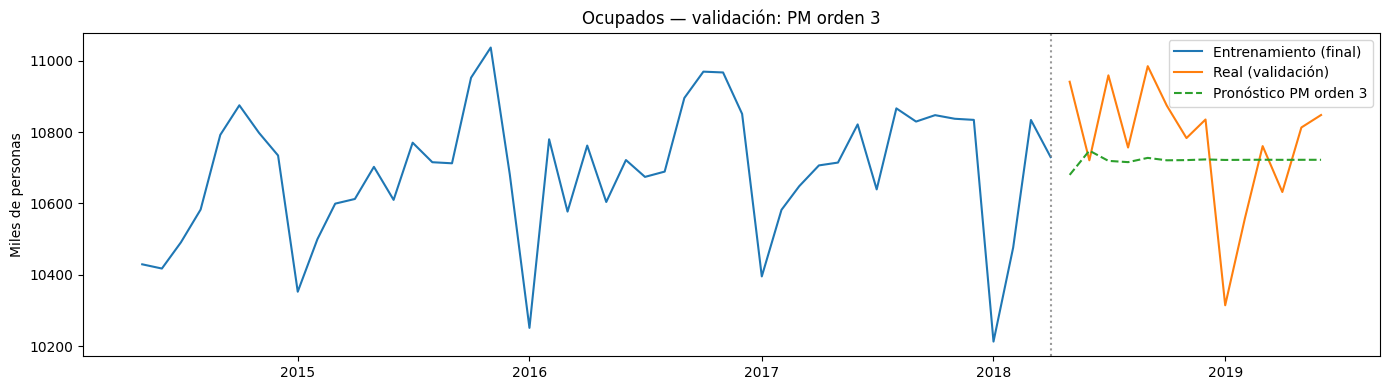

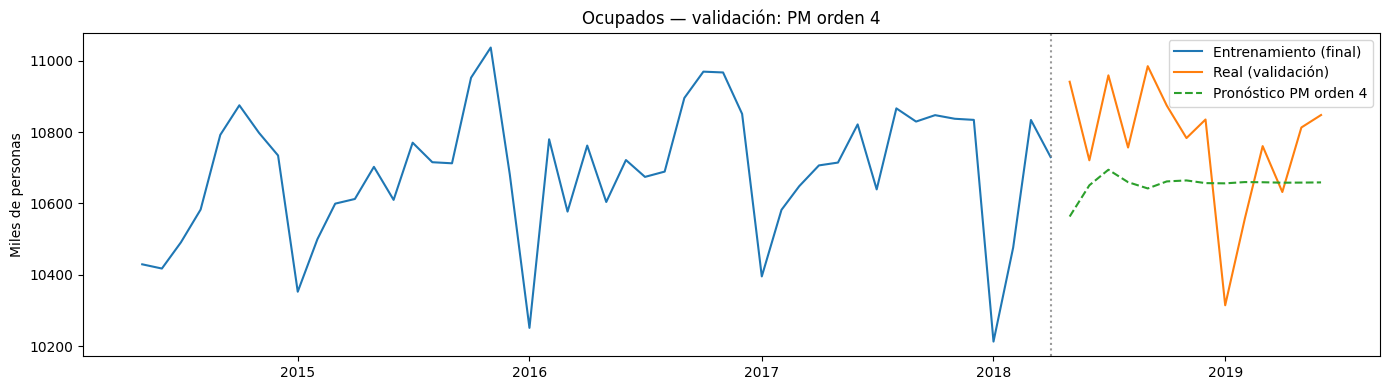

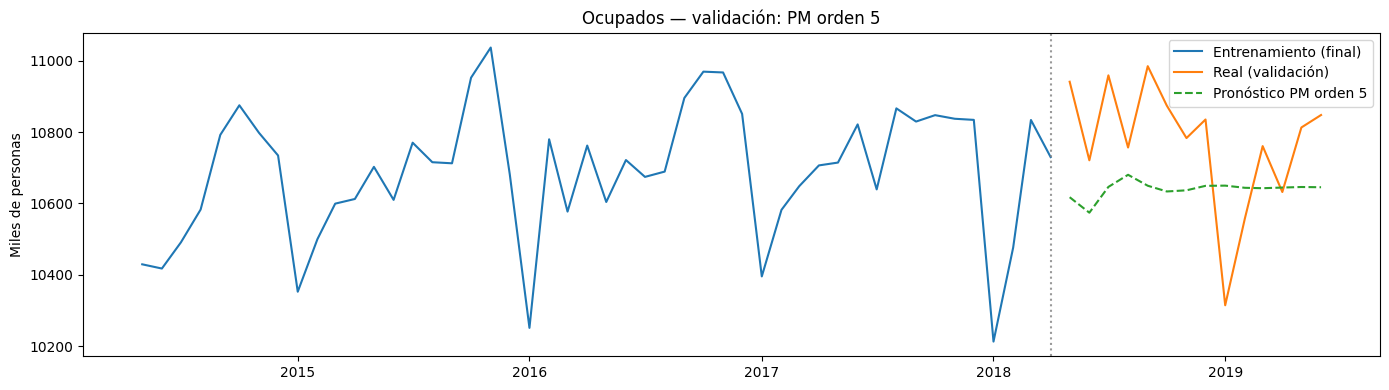

In [ ]:
for _, pred, nombre in [
    (2, mao_2_f, "PM orden 2"),
    (3, mao_3_f, "PM orden 3"),
    (4, mao_4_f, "PM orden 4"),
    (5, mao_5_f, "PM orden 5"),
]:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train_ocup.index[-48:], train_ocup.iloc[-48:], label="Entrenamiento (final)", color="C0")
    ax.plot(test_ocup.index, test_ocup.values, label="Real (validación)", color="C1")
    ax.plot(pred.index, pred.values, label=f"Pronóstico {nombre}", linestyle="--", color="C2")
    ax.axvline(train_ocup.index[-1], color="gray", linestyle=":", alpha=0.8)
    ax.set_ylabel("Miles de personas")
    ax.set_title(f"Ocupados — validación: {nombre}")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
rmse_mao_2 = np.sqrt(mean_squared_error(test_ocup, mao_2_f))
rmse_mao_3 = np.sqrt(mean_squared_error(test_ocup, mao_3_f))
rmse_mao_4 = np.sqrt(mean_squared_error(test_ocup, mao_4_f))
rmse_mao_5 = np.sqrt(mean_squared_error(test_ocup, mao_5_f))

tabla_ma = pd.DataFrame(
    {
        "orden_w": [2, 3, 4, 5],
        "RMSE_validacion": [rmse_mao_2, rmse_mao_3, rmse_mao_4, rmse_mao_5],
    }
).sort_values("RMSE_validacion").reset_index(drop=True)
display(tabla_ma)

mejor_w = int(tabla_ma.iloc[0]["orden_w"])
mejor_rmse = float(tabla_ma.iloc[0]["RMSE_validacion"])
print(
    f"Mejor promedio móvil (menor RMSE en validación): orden w = {mejor_w}  (RMSE = {mejor_rmse:.4f})"
)


,orden_w,RMSE_validacion
0,2,169.187880
1,3,181.438639
2,4,212.784428
3,5,217.054242


Mejor promedio móvil (menor RMSE en validación): orden w = 2  (RMSE = 169.1879)


,Ocupados_pronosticado_miles
mes,
2019-07-01,10830.500000
2019-08-01,10839.250000
2019-09-01,10834.875000
2019-10-01,10837.062500
2019-11-01,10835.968750
2019-12-01,10836.515625


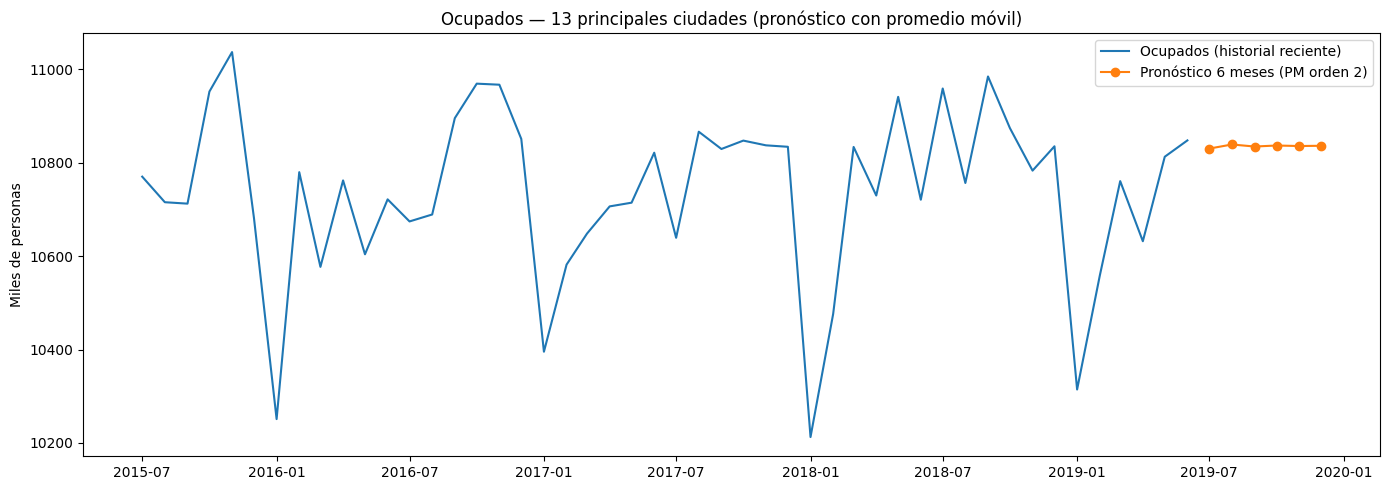

In [ ]:
pronostico_6 = fore_ma(serie_ocup, mejor_w, 6)
tabla_pronostico = pd.DataFrame(
    {"Ocupados_pronosticado_miles": pronostico_6.values},
    index=pronostico_6.index,
)
tabla_pronostico.index.name = "mes"
display(tabla_pronostico)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_ocup.index[-48:], serie_ocup.iloc[-48:], label="Ocupados (historial reciente)")
ax.plot(
    pronostico_6.index,
    pronostico_6.values,
    marker="o",
    label=f"Pronóstico 6 meses (PM orden {mejor_w})",
)
ax.set_ylabel("Miles de personas")
ax.set_title("Ocupados — 13 principales ciudades (pronóstico con promedio móvil)")
ax.legend()
plt.tight_layout()
plt.show()
